> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

# Chapter 2 — Diffusion Models for Life Sciences (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)

**Companion notebook to _LangChain for Life Sciences and Healthcare_.** Diffusion models learn to reverse a gradual corruption process. Here we implement the mechanics in a small 2D setting, visualize forward and reverse processes, discuss conditioning and guidance, and build a life-science evaluation card. Generated samples are candidates for downstream validation, not discoveries or clinical evidence.

## Learning objectives

Explain the forward process, construct a noise schedule, train a small noise predictor, sample with a reverse process, compare generated and reference distributions, and specify domain-appropriate validation for images, molecules, proteins, and omics.

This notebook surveys model families used in modern AI workflows for life sciences and agentic applications. The added notes explain what each model class is good at, how to reason about trade-offs, and how to map the examples to current libraries.

> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

## Environment and guardrails

The core notebook is CPU friendly. The optional `diffusers` section is intentionally disabled by default: it is not required to learn diffusion mechanics and should not be run against clinical imagery without governance, validation, and documented data rights.

<details>
<summary>Optional setup and installation</summary>

Use this only when you are preparing a fresh environment. The notebook content is written for the modern LangChain 1.x package split.

```bash
%pip install -U langchain langgraph langchain-core langchain-openai langchain-community langchain-text-splitters
```

</details>

In [1]:
# %pip install -q numpy pandas matplotlib seaborn scikit-learn torch
# Optional: %pip install -q diffusers accelerate safetensors
import sys, platform, random, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import pairwise_distances
SEED=42; random.seed(SEED); np.random.seed(SEED); rng=np.random.default_rng(SEED)
print({'python':sys.version.split()[0],'platform':platform.platform(),'seed':SEED})
try:
 import torch
 TORCH=True; torch.manual_seed(SEED); device='cuda' if torch.cuda.is_available() else 'cpu'
except ImportError: TORCH=False; device='cpu'
print('torch:',TORCH,'device:',device)

{'python': '3.12.13', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'seed': 42}
torch: True device: cpu


## Where diffusion fits—and what it does not prove

| Data | Potential task | Minimum validation |
|---|---|---|
| Microscopy | Denoising, restoration, augmentation | Held-out acquisition protocol, artifact analysis, expert review |
| Molecules | 2D/3D candidate generation or conformers | Validity, novelty, property distribution, synthesis and assay |
| Proteins | Backbone/structure-conditioned proposals | Structural checks, sequence filters, wet-lab validation |
| Omics | Conditional simulation | Batch, privacy, rare-state, and biological-signal analysis |

No generated output is a diagnosis, a validated molecule, or a biological conclusion.

## Forward diffusion schedule

For a clean point \(x_0\), the closed-form noisy sample is \(x_t=\sqrt{arlpha_t}x_0+\sqrt{1-arlpha_t}\epsilon\), with \(\epsilon\sim\mathcal{N}(0,I)\). A neural network learns to predict noise conditioned on time and optional context.

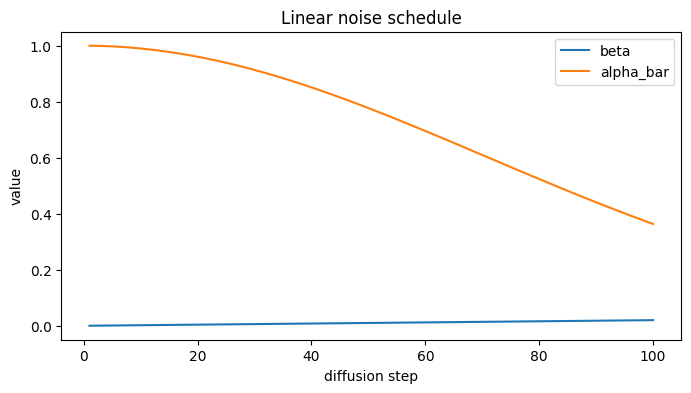

{'beta_1': np.float64(0.0001), 'beta_T': np.float64(0.02), 'alpha_bar_T': np.float64(0.3635632480554922)}


In [2]:
def linear_beta_schedule(T=100,beta_start=1e-4,beta_end=2e-2):
  return np.linspace(beta_start,beta_end,T,dtype=np.float64)
T=100
betas=linear_beta_schedule(T)
alphas=1-betas
alpha_bars=np.cumprod(alphas)

plt.figure(figsize=(8,4))
plt.plot(np.arange(1,T+1),betas,label='beta')
plt.plot(np.arange(1,T+1),alpha_bars,label='alpha_bar')
plt.xlabel('diffusion step')
plt.ylabel('value')
plt.title('Linear noise schedule')
plt.legend()
plt.show()

print({'beta_1':betas[0],'beta_T':betas[-1],'alpha_bar_T':alpha_bars[-1]})

**Forward diffusion:** with the beta schedule defined above, we progressively add Gaussian noise to a clean sample $x_0$ over $T$ steps. The plot below shows the sample at increasing timesteps so you can see the signal dissolve toward pure noise.

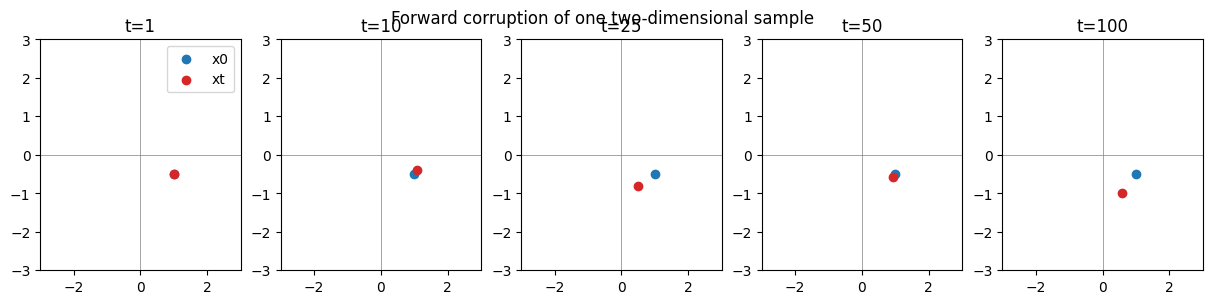

In [3]:
x0=np.array([1.0,-.5])
steps=[0,9,24,49,99]

fig,axs=plt.subplots(1,len(steps),figsize=(15,3))
for ax,t in zip(axs,steps):
    eps=rng.normal(size=2)
    xt=np.sqrt(alpha_bars[t])*x0+np.sqrt(1-alpha_bars[t])*eps
    ax.scatter(*x0,c='tab:blue',label='x0')
    ax.scatter(*xt,c='tab:red',label='xt')
    ax.set(xlim=(-3,3),ylim=(-3,3),title=f't={t+1}')
    ax.axhline(0,color='grey',lw=.5)
    ax.axvline(0,color='grey',lw=.5)
axs[0].legend()
plt.suptitle('Forward corruption of one two-dimensional sample')
plt.show()

## Create a toy scientific distribution

A mixture of Gaussian clusters stands in for multiple experimental regimes. This gives us known ground truth and lets us diagnose mode coverage and distribution mismatch rather than relying on attractive samples.

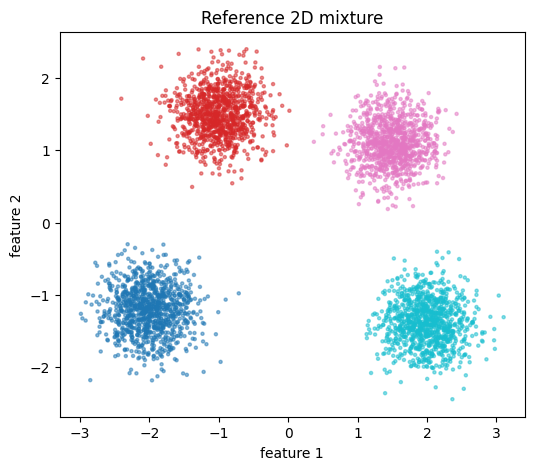

In [4]:
centers=np.array([[-2,-1.2],[-1.0,1.5],[1.5,1.1],[2.0,-1.4]])
def make_data(n=4000):
    labels=rng.integers(0,len(centers),n)
    return centers[labels]+rng.normal(scale=.32,size=(n,2)),labels

x_data,labels=make_data()
plt.figure(figsize=(6,5))
plt.scatter(x_data[:,0],x_data[:,1],c=labels,s=5,cmap='tab10',alpha=.5)
plt.title('Reference 2D mixture')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

## Time embeddings and a minimal noise predictor

This model is deliberately small. It predicts the injected noise from \(x_t\) and normalized time. A real scientific model needs train/validation/test splits defined before training, robust data normalization, and metrics appropriate to the scientific modality.

In [5]:
if not TORCH: raise ImportError('Install torch to run the training cells.')
import torch.nn as nn, torch.nn.functional as F
class NoisePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(3,128),nn.SiLU(),nn.Linear(128,128),nn.SiLU(),nn.Linear(128,2))
    def forward(self,x,t):
      return self.net(torch.cat([x,t[:,None]],dim=1))

model=NoisePredictor().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=2e-3)
x_tensor=torch.tensor(x_data,dtype=torch.float32,device=device)
alpha_t=torch.tensor(alpha_bars,dtype=torch.float32,device=device)
print(model)

NoisePredictor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


This cell illustrates a **diffusion-model** concept. The main idea is to learn how to reverse a gradual noising process so the model can reconstruct structured samples from noise in a controlled sequence of steps.

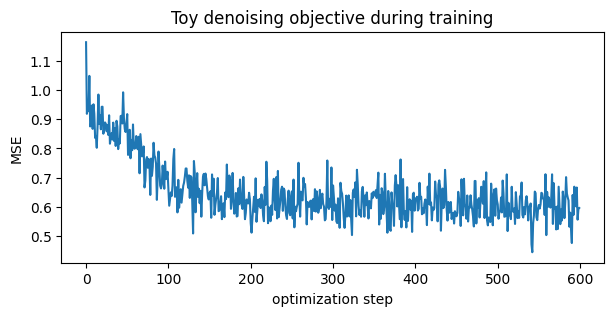

In [6]:
# 600 short CPU-friendly optimization steps; increase only after establishing a held-out evaluation protocol.
losses=[]; model.train()
for step in range(600):
    idx=torch.randint(0,len(x_tensor),(256,),device=device)
    x=x_tensor[idx]
    t=torch.randint(0,T,(len(x),),device=device)
    eps=torch.randn_like(x)
    a=alpha_t[t,None]
    xt=torch.sqrt(a)*x+torch.sqrt(1-a)*eps
    pred=model(xt,t.float()/(T-1))
    loss=F.mse_loss(pred,eps)
    optimizer.zero_grad()
    loss.backward();optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(7,3))
plt.plot(losses)
plt.title('Toy denoising objective during training')
plt.xlabel('optimization step')
plt.ylabel('MSE')
plt.show()

## Reverse sampling

The sampling loop begins from Gaussian noise and iteratively uses the learned noise estimate. It is an educational DDPM-style sampler, not an optimized implementation. Sampling settings are part of the experimental record and must be saved with every generated artifact.

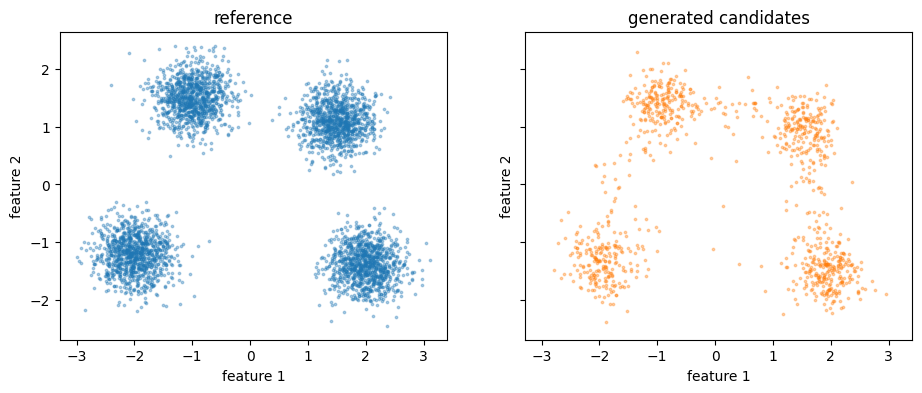

In [7]:
@torch.no_grad()
def sample(n=1000):
    model.eval(); x=torch.randn(n,2,device=device)
    for t in range(T-1,-1,-1):
        tt=torch.full((n,),t,device=device,dtype=torch.long); beta=float(betas[t]); alpha=float(alphas[t]); abar=float(alpha_bars[t])
        eps=model(x,tt.float()/(T-1)); mean=(x-(beta/np.sqrt(1-abar))*eps)/np.sqrt(alpha)
        x=mean if t==0 else mean+np.sqrt(beta)*torch.randn_like(x)
    return x.cpu().numpy()
generated=sample()
fig,axs=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True)
axs[0].scatter(x_data[:,0],x_data[:,1],s=3,alpha=.35);axs[0].set_title('reference')
axs[1].scatter(generated[:,0],generated[:,1],s=3,alpha=.35,c='tab:orange');axs[1].set_title('generated candidates')
for ax in axs: ax.set_xlabel('feature 1');ax.set_ylabel('feature 2')
plt.show()

## Quantitative diagnostics

A low training loss is insufficient. This compact scorecard reports moments, nearest-neighbor distance, and a crude cluster-coverage proxy. These are not substitutes for chemistry, biology, or imaging validation—they demonstrate the expectation that generation is evaluated quantitatively.

In [8]:
def distribution_scorecard(reference,generated,centers):
    nearest=pairwise_distances(generated,reference).min(axis=1)
    assigned=np.argmin(pairwise_distances(generated,centers),axis=1)
    return pd.Series({'reference_mean_x':reference[:,0].mean(),'generated_mean_x':generated[:,0].mean(),'reference_sd_x':reference[:,0].std(),'generated_sd_x':generated[:,0].std(),'mean_nearest_reference_distance':nearest.mean(),'covered_modes':len(np.unique(assigned)),'expected_modes':len(centers)})
scorecard=distribution_scorecard(x_data,generated,centers);scorecard

,0
reference_mean_x,0.113714
generated_mean_x,0.221423
reference_sd_x,1.708013
generated_sd_x,1.633184
mean_nearest_reference_distance,0.041976
covered_modes,4.000000
expected_modes,4.000000


**Evaluating samples:** the scorecard above measures how close generated points land to the reference modes. The KDE comparison below overlays the true data distribution against the model's samples so you can judge coverage and fidelity visually.

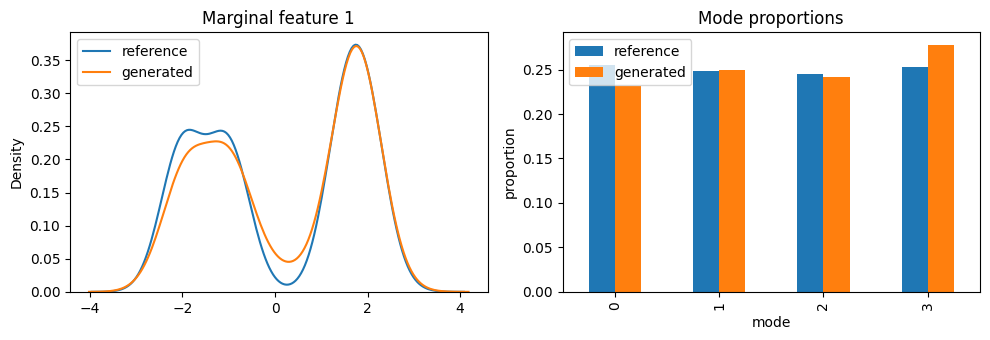

In [9]:
fig,axs=plt.subplots(1,2,figsize=(10,3.5));sns.kdeplot(x=x_data[:,0],ax=axs[0],label='reference');sns.kdeplot(x=generated[:,0],ax=axs[0],label='generated');axs[0].legend();axs[0].set_title('Marginal feature 1')
ref_counts=np.bincount(np.argmin(pairwise_distances(x_data,centers),axis=1),minlength=4)/len(x_data);gen_counts=np.bincount(np.argmin(pairwise_distances(generated,centers),axis=1),minlength=4)/len(generated)
pd.DataFrame({'reference':ref_counts,'generated':gen_counts}).plot.bar(ax=axs[1]);axs[1].set_title('Mode proportions');axs[1].set_xlabel('mode');axs[1].set_ylabel('proportion');plt.tight_layout();plt.show()

## Conditioning and classifier-free guidance

Conditioning asks for samples consistent with a variable such as assay context, protein pocket, imaging protocol, or phenotype. The variable must be available at inference, scientifically meaningful, and split without leakage. Guidance can improve apparent adherence while reducing diversity; report a guidance sweep rather than one attractive setting.

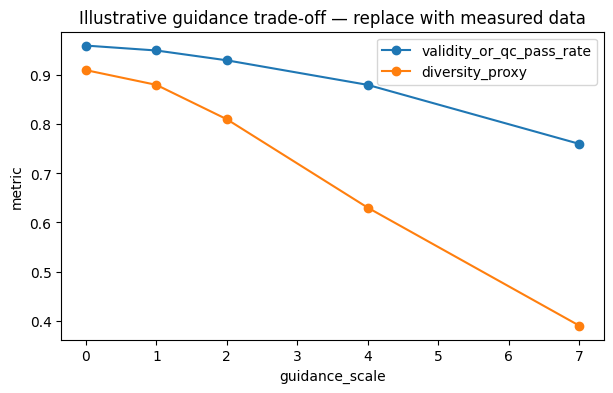

In [10]:
guidance_sweep=pd.DataFrame({'guidance_scale':[0,1,2,4,7],'validity_or_qc_pass_rate':[0.96,0.95,0.93,0.88,0.76],'diversity_proxy':[0.91,0.88,0.81,0.63,0.39]})
ax=guidance_sweep.plot(x='guidance_scale',y=['validity_or_qc_pass_rate','diversity_proxy'],marker='o',figsize=(7,4));ax.set_title('Illustrative guidance trade-off — replace with measured data');ax.set_ylabel('metric');plt.show()
# This table is didactic only; do not use its values as experimental results.

## Life-science generation evaluation card

Use this template for every experiment. It makes the model, data, conditioning, candidate filters, and scientific validation explicit.

In [11]:
evaluation_card={
 'dataset':{'name':'TOY_2D_MIXTURE','version':'1.0','license':'synthetic','split_policy':'random only for pedagogy; use temporal/scaffold/specimen splits in research'},
 'model':{'family':'DDPM-style MLP','timesteps':T,'seed':SEED,'device':device},
 'generation':{'n_samples':int(len(generated)),'conditioning':'none','guidance_scale':None},
 'automated_metrics':scorecard.to_dict(),
 'domain_validation':{'molecules':['RDKit validity','uniqueness','novelty','scaffold diversity','property distributions','synthesis/assay'], 'images':['protocol-held-out QC','artifact review','expert assessment'], 'proteins':['structure/sequence filters','experimental assay']},
 'limitations':['toy distribution','no external validation','generated points are not scientific candidates']}
print(json.dumps(evaluation_card,indent=2,default=float))

{
  "dataset": {
    "name": "TOY_2D_MIXTURE",
    "version": "1.0",
    "license": "synthetic",
    "split_policy": "random only for pedagogy; use temporal/scaffold/specimen splits in research"
  },
  "model": {
    "family": "DDPM-style MLP",
    "timesteps": 100,
    "seed": 42,
    "device": "cpu"
  },
  "generation": {
    "n_samples": 1000,
    "conditioning": "none",
    "guidance_scale": null
  },
  "automated_metrics": {
    "reference_mean_x": 0.11371369192364122,
    "generated_mean_x": 0.22142302989959717,
    "reference_sd_x": 1.7080132213018775,
    "generated_sd_x": 1.6331844329833984,
    "mean_nearest_reference_distance": 0.04197556322331258,
    "covered_modes": 4.0,
    "expected_modes": 4.0
  },
  "domain_validation": {
    "molecules": [
      "RDKit validity",
      "uniqueness",
      "novelty",
      "scaffold diversity",
      "property distributions",
      "synthesis/assay"
    ],
    "images": [
      "protocol-held-out QC",
      "artifact review",
      "e

## Molecules, proteins, images, and omics: correct next steps

- **Molecules:** choose graph, 3D, or sequence representation; report validity, uniqueness, novelty against the *training* set, scaffold diversity, property distributions, and synthesis/assay outcomes.
- **Proteins:** distinguish structure-conditioned backbone generation from sequence generation; apply structural and experimental filters.
- **Images:** evaluate at patient/specimen/protocol level, audit hallucinated or removed structures, and retain original pixels and acquisition metadata.
- **Omics:** test whether generation preserves biology rather than batch; assess rare states, privacy leakage, and downstream differential-analysis distortion.

Never use synthetic medical images as diagnostic evidence without a validated, governed workflow.

## Optional `diffusers` integration

Keep this disabled until you have an appropriate, redistributable non-clinical dataset. The goal is to reuse schedulers and pipelines—not to skip split design, metadata capture, or scientific validation.

```python
RUN_DIFFUSERS = False
if RUN_DIFFUSERS:
    from diffusers import DDPMScheduler, UNet2DModel
    # Load a public non-clinical dataset, define protocol-level splits,
    # train, save config + seed, and fill the evaluation card above.
```

## Exercises

1. Change the beta schedule and compare convergence, coverage, and nearest-reference distance.
2. Hold out one Gaussian mode and test whether the model memorizes or extrapolates.
3. Add an observed condition label to the toy model and evaluate condition adherence plus diversity.
4. Implement a molecule-generation evaluation harness that requires RDKit checks and a time/scaffold split before samples are displayed.

## Check your understanding

Use these tasks to test understanding before moving on. Expand each spoiler only after you have tried the problem yourself.

### Exercise 1
**Task:** In one or two sentences, explain the difference between the forward (noising) and reverse (denoising) processes in a diffusion model.

<details><summary>Show sample answer</summary>

The forward process gradually adds Gaussian noise to data until it becomes (almost) pure noise, while the reverse process learns to iteratively remove that noise to recover or generate realistic samples.

</details>

### Exercise 2
**Task:** Why does the choice of beta (noise) schedule matter for training stability and sample quality?

<details><summary>Show sample answer</summary>

The schedule controls how quickly information is destroyed; too aggressive a schedule makes the reverse steps hard to learn, while too gentle a schedule wastes computation and can leave residual noise in samples.

</details>

### Exercise 3
**Task:** Give one reason molecule generation needs extra validation beyond visual inspection of samples.

<details><summary>Show sample answer</summary>

Plausible-looking outputs can still be chemically invalid, so generated structures must pass checks such as RDKit sanitization, valence rules, and novelty/scaffold-split evaluation before they are trusted.

</details>

## Open-ended tasks (self-learning)

These have no single right answer. They push you from "ran the cells" to "can reason about generative-model design for molecules."

**Task A — Schedule sensitivity.** Change the beta schedule (e.g. linear → cosine, or fewer/more steps $T$) and re-run the toy forward/reverse process. How does sample quality (nearest-reference distance) and runtime change? Argue for the schedule you would keep for a real molecule generator.

**Task B — Memorization vs. generalization.** Hold out one Gaussian mode during training, then sample. Does the model recover the missing mode (generalize) or only reproduce the seen modes (memorize)? Why does this distinction matter so much for *de novo* drug design?

**Task C — Conditioning.** Sketch (or implement) how you would condition the toy diffusion model on a desired property (e.g. "high solubility"). What changes in the inputs, the loss, and the sampling loop? Name one risk of property-conditioned generation in a therapeutic context.

**Task D — Validity gate.** Describe a post-generation filter stack for molecules (RDKit sanitization → valence/SA score → scaffold novelty vs. training set). At which stage would you reject the most candidates, and what is the cost of being too strict vs. too lenient?